   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000
YearsExperience    0
Salary             0
dtype: int64
Best Parameters: {'n_neighbors': 2, 'weights': 'uniform'}

Model Comparison
               Model  R

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


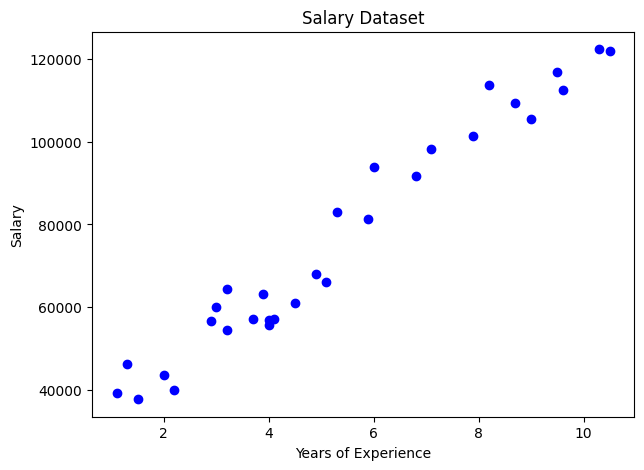

In [37]:
# ==========================
# Import Libraries
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ==========================
# Load Dataset
# ==========================
df = pd.read_csv("Salary_Data.csv")

print(df.head())
print(df.info())
print(df.describe())

# ==========================
# Check Missing Values
# ==========================
print(df.isnull().sum())

# ==========================
# Features & Target
# ==========================
X = df[['YearsExperience']]
y = df['Salary']

# ==========================
# Train Test Split
# ==========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================
# Feature Scaling
# ==========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================
# Hyperparameter Tuning (KNN)
# ==========================
params = {
    'n_neighbors':[2,3,4,5,6,7,8],
    'weights':['uniform','distance']
}

grid = GridSearchCV(
    KNeighborsRegressor(),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

# ==========================
# Models
# ==========================
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor(**grid.best_params_),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(kernel='rbf')
}

results = []

# ==========================
# Training & Evaluation
# ==========================
for name, model in models.items():

    # Models requiring scaling
    if name in ["KNN", "SVR"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results.append([name, r2, mae, rmse])

# ==========================
# Result Table
# ==========================
results_df = pd.DataFrame(
    results,
    columns=["Model", "R2 Score", "MAE", "RMSE"]
)

print("\nModel Comparison")
print(results_df.sort_values(by="R2 Score", ascending=False))

# ==========================
# Best Model
# ==========================
best = results_df.loc[results_df["R2 Score"].idxmax()]

print("\n==============================")
print("Best Model")
print("==============================")
print(best)

# ==========================
# Train Best Model Again
# ==========================
best_model = KNeighborsRegressor(**grid.best_params_)
best_model.fit(X_train_scaled, y_train)

# ==========================
# Predict New Salary
# ==========================
experience = [[7.5]]

experience_scaled = scaler.transform(experience)

prediction = best_model.predict(experience_scaled)

print("\nPredicted Salary for 7.5 years experience:")
print(prediction[0])

# ==========================
# Visualization
# ==========================
plt.figure(figsize=(7,5))
plt.scatter(X, y, color='blue')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Dataset")
plt.show()

In [38]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

# KNN with n_neighbors=3
knn3 = KNeighborsRegressor(n_neighbors=3)
knn3.fit(X_train_scaled, y_train)

pred3 = knn3.predict(X_test_scaled)

print("KNN (k=3):", r2_score(y_test, pred3))


# KNN with n_neighbors=2
knn2 = KNeighborsRegressor(n_neighbors=2)
knn2.fit(X_train_scaled, y_train)

pred2 = knn2.predict(X_test_scaled)

print("KNN (k=2):", r2_score(y_test, pred2))

KNN (k=3): 0.9407212188647607
KNN (k=2): 0.9217065509837155


In [39]:
knn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [40]:
knn.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=3)